In [ ]:
from src.utils import get_data_env
from src.models import GATv2Model, NodeRFModel
from src.dataloading import DeepDataLoader, ShallowDataLoader

disease_name    = 'measles'
nuts_level      = 'nuts2'
min_date        ='2006-05-15'
max_date        = '2019-06-01'
split_trainval  = '2017-01-01'
split_valtest   = '2018-01-01'
split_berlin    = False

horizon_size    = 4
horizon_leadtime= 1
sequence_length = 1
lags            = 4

graphtype       = 'boolean_neighbors_self'
modelname       = 'boolean neighbors - spatial gcn'

# training hparams
n_epochs        = 150
lr              = 0.0001
min_delta       = 0
loss            = 'asymmetric_mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.8, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


logged_zscore = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
logged_zscore.add_time_features()
logged_zscore.log_transform_target()
logged_zscore.set_splits(split_trainval, split_valtest)
logged_zscore.normalize()
logged_zscore.add_lagged_features(lags = lags)
logged_zscore.finalize()

dl1 = logged_zscore.copy().retrieve_graph('boolean_neighbors_self0').construct_dataloaders()

# ml1      = GATv2Model(dl1, name = 'boolean neighbors graph')
# ml1.set_model_hparams()
# ml1.set_global_hparams(**global_hparams)
# ml1.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
# ml1.forecast('test')
# ml1.show_forecasts('test', [26,391, 69], show_all_horizons=True)

# dl2 = logged_zscore.copy().retrieve_graph('gravity4').construct_dataloaders()

# ml2      = GATv2Model(dl2, name = 'gravity model 4 graph')
# ml2.set_model_hparams()
# ml2.set_global_hparams(**global_hparams)
# ml2.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
# ml2.forecast('test')
# ml2.show_forecasts('test', [26,391, 69], show_all_horizons=True)

# dl3 = logged_zscore.copy().retrieve_graph('commuter1').construct_dataloaders()

# ml3      = GATv2Model(dl3, name = 'commuter 1 graph')
# ml3.set_model_hparams()
# ml3.set_global_hparams(**global_hparams)
# ml3.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
# ml3.forecast('test')
# ml3.show_forecasts('test', [26,391, 69], show_all_horizons=True)

# epidata_loader_basis = ShallowDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
# epidata_loader_basis.add_time_features()
# epidata_loader_basis.log_transform_target()
# epidata_loader_basis.set_splits(split_trainval, split_valtest)
# epidata_loader_basis.normalize()
# epidata_loader_basis.add_lagged_features(lags = lags)
# epidata_loader_basis.finalize()

# epidata_loader_basis.construct_dataloaders()

# rfmodel = NodeRFModel(epidata_loader_basis, name = 'node RF')
# rfmodel.set_global_hparams()
# rfmodel.set_model_hparams()
# rfmodel.train()
# rfmodel.forecast('test')
# rfmodel.show_forecasts('test',0, show_all_horizons=True)

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-10 (+5 weeks)


In [28]:
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import traincolor, valcolor, testcolor


In [44]:
selff = dl1

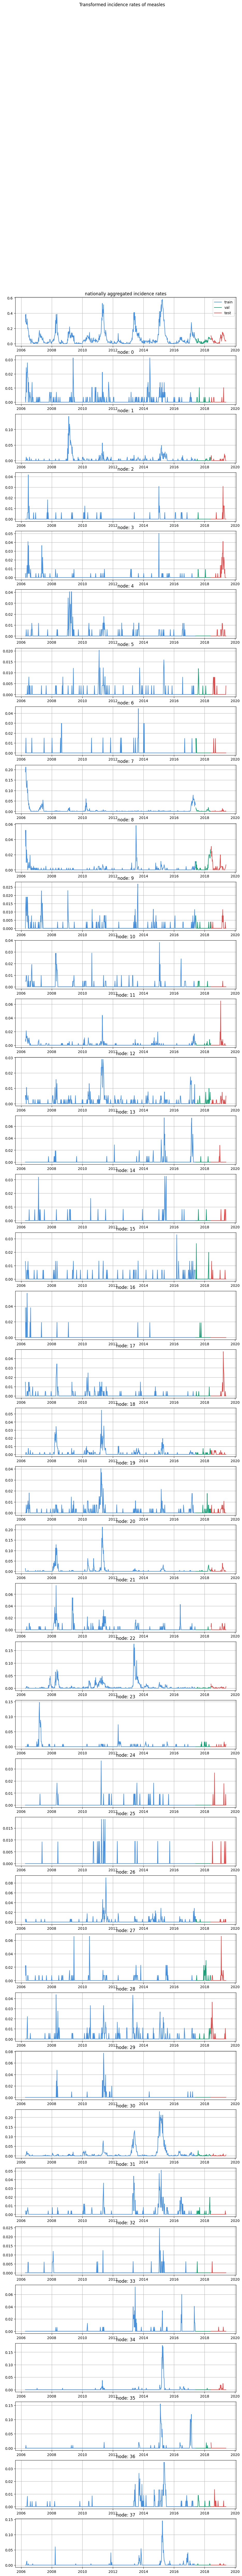

In [15]:
dataset

,timestamp,incidence,node
0,2006-04-10,0.000000,0
1,2006-04-10,0.042487,1
2,2006-04-10,0.000000,2
3,2006-04-10,0.000000,3
4,2006-04-10,0.000000,4
...,...,...,...
295195,2020-05-25,0.000000,395
295196,2020-05-25,0.000000,396
295197,2020-05-25,0.000000,397
295198,2020-05-25,0.000000,398
